# Práctica 2: Aprendizaje no supervisado
## Determinación de tipos de estrellas

**Asignatura:** Aprendizaje Automático  
**Grupo de prácticas:** [X]  
**Integrantes:** [Nombre 1, Nombre 2]  
**Semilla base utilizada:** 100495927

## 1. Objetivo

El objetivo de esta práctica es aplicar técnicas de aprendizaje no supervisado para
agrupar estrellas en función de sus características físicas y espectrales.

Para ello, se parte de un conjunto de datos de 240 estrellas y se comparan tres
algoritmos de clustering:
- K-Means
- Clustering jerárquico
- DBSCAN

Siguiendo el enunciado, antes del clustering se reduce la dimensionalidad a 2
componentes principales mediante PCA. Finalmente, se recomienda un pipeline de
clustering y se compara con las clases astronómicas habituales.


In [9]:
# Instalación de dependencias necesarias
%pip install numpy pandas matplotlib seaborn scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram

SEED = 100495927  
np.random.seed(SEED)

En esta práctica se fija una semilla para garantizar la reproducibilidad de los
resultados, tal y como exige el enunciado.

In [11]:
df = pd.read_csv("stars_data.csv")  # revisar nombre exacto del fichero
df.head()

,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


In [12]:
df.shape, df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
dtypes: float64(3), int64(1), str(2)
memory usage: 11.4 KB


((240, 6), None)

In [13]:
df.describe(include='all')

,Temperature,L,R,A_M,Color,Spectral_Class
count,240.000000,240.000000,240.000000,240.000000,240,240
unique,NaN,NaN,NaN,NaN,17,7
top,NaN,NaN,NaN,NaN,Red,M
freq,NaN,NaN,NaN,NaN,112,111
mean,10497.462500,107188.361635,237.157781,4.382396,NaN,NaN
std,9552.425037,179432.244940,517.155763,10.532512,NaN,NaN
min,1939.000000,0.000080,0.008400,-11.920000,NaN,NaN
25%,3344.250000,0.000865,0.102750,-6.232500,NaN,NaN
50%,5776.000000,0.070500,0.762500,8.313000,NaN,NaN
75%,15055.500000,198050.000000,42.750000,13.697500,NaN,NaN


# 3. Descripción inicial del dataset

El conjunto de datos contiene 240 estrellas y las siguientes variables:
- **Temperature**: Temperatura promedio de la superficie en grados K
- **L**: Luminosidad comparada con el Sol
- **R**: Radio comparado con la del Sol
- **A_M**: Magnitud absoluta 
- **Spectral_Class**: Clasificación espectral
- **Color**: Color principal del espectro

A continuación se revisan tipos de datos, posibles valores categóricos y la existencia
de valores perdidos o inconsistencias.

## 3.1: Limpieza y Consolidación de Datos

Antes de aplicar cualquier algoritmo, es fundamental la calidad de los datos. En este paso comprobaremos la existencia de **valores nulos** o **registros duplicados** que puedan alterar la formación de los clusters.

Además en conjuntos de datos astronómicos es común encontrar inconsistencias tipográficas en variables categóricas introducidas manualmente, como el color de la estrella. Procedemos a estandarizar la variable `Color` (convirtiendo todo a minúsculas y eliminando espacios/guiones redundantes) para evitar que el algoritmo interprete "Red" y "red" como dos categorías distintas.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("1. COMPROBACIÓN DE NULOS Y DUPLICADOS")
print(f"Valores nulos por columna:\n{df.isnull().sum()}\n")
print(f"Filas duplicadas: {df.duplicated().sum()}\n")

print("2. LIMPIEZA DE LA VARIABLE 'Color'")
#Estandarizamos los colores: minúsculas, quitamos espacios extra y cambiamos guiones por espacios
df['Color'] = df['Color'].str.lower().str.strip().str.replace('-', ' ')
print("Valores únicos de Color tras la limpieza:")
print(df['Color'].value_counts())

print("\n3. VALORES DE 'Spectral_Class'")
print(df['Spectral_Class'].value_counts())

1. COMPROBACIÓN DE NULOS Y DUPLICADOS
Valores nulos por columna:
Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64

Filas duplicadas: 0

2. LIMPIEZA DE LA VARIABLE 'Color'
Valores únicos de Color tras la limpieza:
Color
red                   112
blue                   56
blue white             41
white                  10
yellow white            8
yellowish white         3
yellowish               3
whitish                 2
orange                  2
pale yellow orange      1
white yellow            1
orange red              1
Name: count, dtype: int64

3. VALORES DE 'Spectral_Class'
Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64


## 3.2: Análisis Visual: Diagrama Hertzsprung-Russell (HR)

A modo de investigación, vamos a recrear el diagrama más importante de la astrofísica estelar: el *Diagrama Hertzsprung-Russell (HR)*.

Este gráfico es importante porque nos va a mostrar agrupaciones naturales que los algoritmos de clustering no supervisado generarán más adelante. **¿Cómo funciona?** El gráfico relaciona la `Temperatura superficial` (eje X) con la `Magnitud Absoluta` o luminosidad (eje Y). Las estrellas más calientes quedarán a la izquierda (invertiremos los ejes) y las más brillantes en la parte superior.

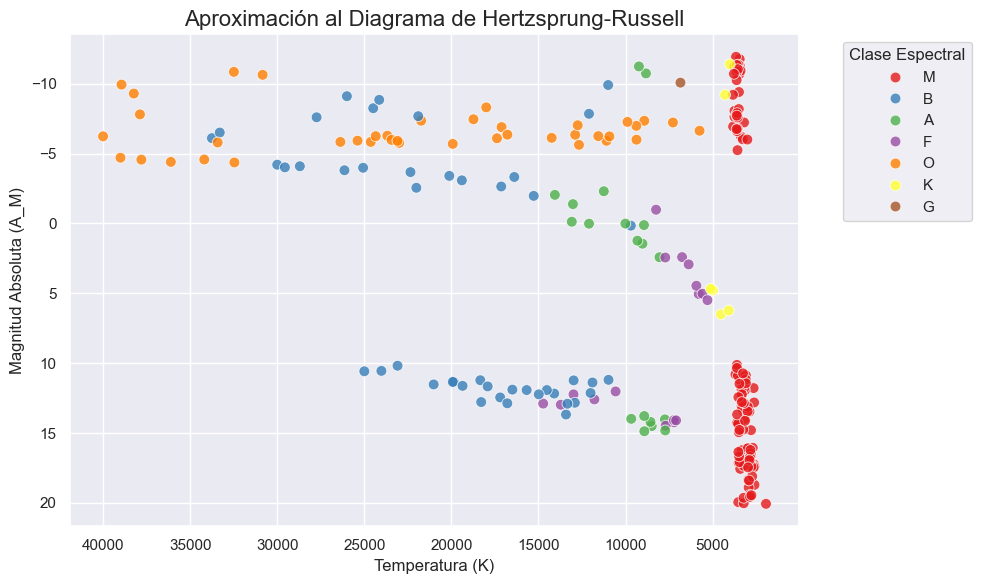

In [15]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))

#Dibujamos Temperatura vs Magnitud Absoluta
sns.scatterplot(data=df, x='Temperature', y='A_M', hue='Spectral_Class', palette='Set1', s=60, alpha=0.8)

#Para que cumpla el estándar astronómico, invertimos los ejes
plt.gca().invert_xaxis()  
plt.gca().invert_yaxis() 

plt.title("Aproximación al Diagrama de Hertzsprung-Russell", fontsize=16)
plt.xlabel("Temperatura (K)", fontsize=12)
plt.ylabel("Magnitud Absoluta (A_M)", fontsize=12)
plt.legend(title='Clase Espectral', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3.3: Preprocesamiento: Escalado y Codificación

Los algoritmos de clustering que utilizaremos (K-Means, Jerárquico y DBSCAN) se basan en el cálculo de distancias matemáticas entre las instancias. Esto nos obliga a realizar dos transformaciones críticas:

1. *Codificación de variables categóricas*: Algoritmos basados en distancias no pueden procesar texto. Aplicaremos un `OneHotEncoder` a las variables **Color** y **Spectral_Class** para transformarlas en representaciones binarias.

2. *Escalado de variables numéricas*: Las variables tienen raangos abismalmente distintos. Si no las escalamos, la temperatura dominaría por completo el cáclulo de la distancia. Utilizaremos `StandarScaler` para que todas las variables numéricas tengan media 0 y varianza 1, asegurando que todas contribuyan equitativamente al clustering

In [16]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

print(" PREPROCESAMIENTO PARA CLUSTERING ")

# 1. Separamos variables
columnas_num = ['Temperature', 'L', 'R', 'A_M']
columnas_cat = ['Color', 'Spectral_Class']

# 2. Creamos el preprocesador
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_num),
        # Usamos sparse_output=False para que devuelva un array denso normal
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), columnas_cat) 
    ])

# 3. Aplicamos la transformación a los datos
X_procesado = preprocesador.fit_transform(df)

# 4. Recuperamos los nombres de las columnas para no perder la pista
nombres_num = columnas_num
nombres_cat = preprocesador.named_transformers_['cat'].get_feature_names_out(columnas_cat)
nombres_todos = list(nombres_num) + list(nombres_cat)

# 5. Lo volvemos a meter en un DataFrame para que sea fácil trabajar con él
df_procesado = pd.DataFrame(X_procesado, columns=nombres_todos)

print(f"Dimensiones del dataset original: {df.shape}")
print(f"Dimensiones del dataset procesado (tras OneHotEncoding): {df_procesado.shape}")
display(df_procesado.head())

 PREPROCESAMIENTO PARA CLUSTERING 
Dimensiones del dataset original: (240, 6)
Dimensiones del dataset procesado (tras OneHotEncoding): (240, 23)


,Temperature,L,R,A_M,Color_blue,Color_blue white,Color_orange,Color_orange red,Color_pale yellow orange,Color_red,...,Color_yellow white,Color_yellowish,Color_yellowish white,Spectral_Class_A,Spectral_Class_B,Spectral_Class_F,Spectral_Class_G,Spectral_Class_K,Spectral_Class_M,Spectral_Class_O
0,-0.779382,-0.598624,-0.459210,1.116745,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.782110,-0.598624,-0.459241,1.162414,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.828477,-0.598624,-0.459342,1.362213,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.807496,-0.598624,-0.459229,1.167171,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.897819,-0.598624,-0.459340,1.491607,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# 4. Reducción de Dimensionalidad con PCA

Tras el preprocesamiento, nuestro conjunto de datos ha aumentado a 23 dimensiones debido a la codificación *One-Hot* de las variables categóricas. Trabajar con alta dimensionalidad en algoritmos basados en distancias puede provocar lo que se conoce como **'la maldición de la dimensionalidad'**.

Siguiendo los requisitos de la práctica, aplicaremos el **Análisis de Componentes Principales (PCA)** para reducir estrictamente nuestro espacio a 2 componentes. Esto no solo nos permitirá visualizar nuestros datos en un plano 2D antes y después del clustering, sino que forzará a los algoritmos a agrupar basándose en las direcciones de máxima varianza de nuestros datos estelares. Analizaremos cuánta información logramos retener con solo 2 ejes.

 4. REDUCCIÓN DE DIMENSIONALIDAD (PCA a 2D) 
Varianza explicada por PC1: 47.93%
Varianza explicada por PC2: 23.79%
Varianza TOTAL retenida en 2D: 71.72%



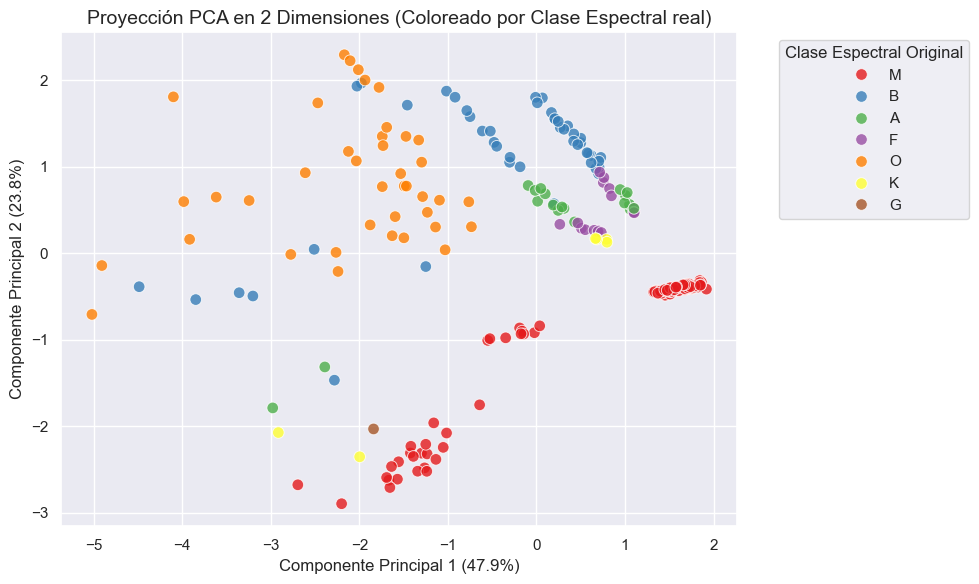

In [17]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

print(" 4. REDUCCIÓN DE DIMENSIONALIDAD (PCA a 2D) ")

# 1. Instanciamos PCA forzando 2 componentes
pca = PCA(n_components=2, random_state=SEED)

# 2. Aplicamos PCA sobre nuestros datos ya procesados (escalados y codificados)
componentes_principales = pca.fit_transform(df_procesado)

# 3. Creamos un nuevo DataFrame con las dos componentes
df_pca = pd.DataFrame(data=componentes_principales, columns=['PC1', 'PC2'])

# 4. Comprobamos cuánta "información" hemos retenido
varianza_explicada = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {varianza_explicada[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {varianza_explicada[1]*100:.2f}%")
print(f"Varianza TOTAL retenida en 2D: {sum(varianza_explicada)*100:.2f}%\n")

# 5. Visualizamos el resultado
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_pca['PC1'], 
    y=df_pca['PC2'], 
    hue=df['Spectral_Class'], 
    palette='Set1',
    s=70, 
    alpha=0.8
)
plt.title('Proyección PCA en 2 Dimensiones (Coloreado por Clase Espectral real)', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({varianza_explicada[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({varianza_explicada[1]*100:.1f}%)')
plt.legend(title='Clase Espectral Original', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()